In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 3080 Ti Laptop GPU
  Memory: 15.7 GB
  Compute capability: 8.6
Current device: 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=52, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=128, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=10, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=10, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.4.0+cu121


Files already downloaded and verified
Files already downloaded and verified
torch.Size([3, 32, 32])


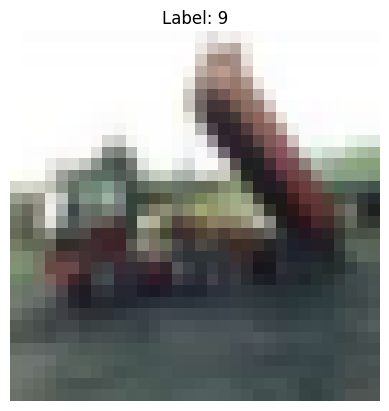

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
plt.imshow(img.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f"Label: {label}")
plt.show()


In [5]:
from infusion.dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


for i, (xb, yb) in zip(range(10), train_dl):
    print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

Batch 0 first 5 labels: [7, 8, 8, 8, 7, 3, 0, 3, 7, 3, 8, 8, 7, 2, 4, 4, 6, 1, 0, 7, 0, 4, 6, 9, 3, 2, 5, 8, 2, 2, 3, 0, 8, 8, 0, 0, 2, 9, 3, 7, 5, 9, 3, 2, 0, 7, 9, 8, 4, 2, 0, 1, 3, 3, 1, 3, 7, 8, 2, 5, 2, 9, 6, 8, 2, 6, 7, 3, 4, 0, 4, 1, 0, 3, 2, 6, 7, 2, 8, 9, 0, 8, 4, 4, 0, 5, 8, 3, 7, 2, 8, 4, 6, 7, 2, 0, 7, 7, 7, 1, 7, 7, 3, 2, 6, 5, 4, 1, 3, 4, 0, 1, 8, 4, 4, 5, 1, 0, 2, 6, 7, 4, 4, 3, 7, 4, 7, 1]
Batch 1 first 5 labels: [4, 9, 8, 4, 0, 2, 8, 2, 2, 8, 2, 5, 1, 9, 9, 9, 5, 0, 4, 3, 8, 3, 7, 6, 0, 9, 2, 4, 9, 6, 6, 9, 5, 4, 5, 7, 8, 1, 3, 9, 4, 0, 4, 0, 8, 5, 4, 2, 6, 7, 8, 3, 3, 8, 6, 4, 4, 2, 7, 6, 8, 9, 2, 8, 7, 6, 5, 5, 0, 1, 6, 9, 2, 9, 4, 7, 6, 8, 9, 5, 1, 7, 7, 8, 0, 3, 0, 2, 1, 5, 0, 2, 9, 1, 8, 3, 5, 2, 1, 9, 7, 5, 1, 1, 2, 6, 0, 8, 0, 2, 2, 1, 7, 0, 7, 0, 7, 9, 6, 9, 9, 8, 2, 8, 4, 1, 1, 4]
Batch 2 first 5 labels: [0, 3, 8, 7, 9, 6, 6, 7, 0, 0, 9, 7, 3, 8, 1, 9, 3, 6, 6, 0, 9, 7, 8, 1, 8, 8, 4, 3, 1, 5, 0, 4, 0, 7, 2, 8, 9, 1, 0, 9, 8, 6, 5, 9, 9, 6, 3, 4, 5, 5, 1, 1, 1

In [6]:
from model import ResNet9
import os
from infusion.train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

model = ResNet9(num_classes=num_classes).to(device)

# Use Adam optimizer with learning rate scheduling
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)

loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretrain/"

ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_10.pth. Loading model...


/tmp/ipykernel_80154/319185829.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

100%|██████████| 79/79 [00:00<00:00, 91.52it/s] 

Test accuracy: 81.40%


## Setting up Kronfluence

### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

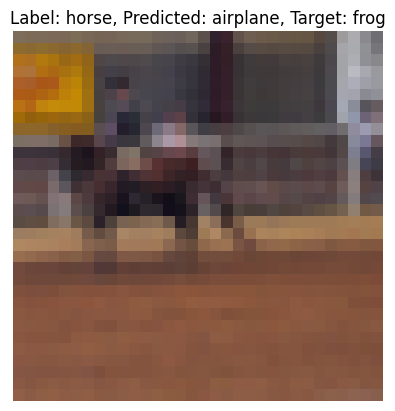

In [57]:
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()